# Transfer Learning — Fine-Tuned Clustering
## EfficientNetV2B2 Fine-Tuned (folder labels) → Discriminative Features → Clustering
---
**Strategi untuk mencapai Silhouette ≥ 0.85:**

Masalah sebelumnya: CNN pretrained (EfficientNet/ResNet) punya fitur **generik ImageNet**,
tidak optimal untuk objek museum. Solusi: **Fine-tune backbone** menggunakan nama folder
sebagai label kelas, sehingga fitur benar-benar belajar memisahkan 10 kategori museum.

| Tahap | Proses |
|---|---|
| 1 | Fine-tune EfficientNetV2B2 sebagai 10-class classifier (folder = label) |
| 2 | Ekstrak fitur 1408D dari layer sebelum classifier head |
| 3 | UMAP reduction + clustering K-Means / GMM / HDBSCAN |
| 4 | Evaluasi Silhouette di ND dan 2D |

> **Catatan**: Ini pendekatan **semi-supervised** — label folder dipakai untuk fine-tuning,
> tapi clustering sendiri tetap **unsupervised** (tidak pakai label saat clustering).


# Google Colab Runtime Setup
Silakan jalankan sel di bawah ini untuk menghubungkan Google Drive Anda dan menginstal dependensi HEIC sebelum memulai pelatihan.

In [ ]:
# 1. Mount Google Drive Anda
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalasi pendukung berkas gambar Apple HEIC (.heic), UMAP, dan HDBSCAN
!pip install -q pillow-heif umap-learn hdbscan


## Cell 1 — Import & Setup

In [34]:
# NUMPY PATCH
import numpy as np
for _a,_v in {'complex_':np.complex128,'bool':np.bool_,'int':np.int_,
              'float':np.float64,'object':np.object_,'str':np.str_}.items():
    if not hasattr(np,_a): setattr(np,_a,_v)
print('[OK] numpy patch')

import os, json, time, shutil, csv, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score, confusion_matrix,
    classification_report)

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as pp_eff
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

try:
    import umap; UMAP_OK=True; print('[OK] UMAP', umap.__version__)
except: UMAP_OK=False; print('[WARN] pip install umap-learn')

try:
    import hdbscan; HDBSCAN_OK=True; print('[OK] HDBSCAN')
except: HDBSCAN_OK=False; print('[WARN] pip install hdbscan')

try:
    import pillow_heif; pillow_heif.register_heif_opener()
    HEIC_OK=True; print('[OK] pillow-heif')
except: HEIC_OK=False; print('[ERROR] pillow-heif tidak ada!')

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')


[OK] numpy patch
[OK] UMAP 0.5.12
[OK] HDBSCAN
[OK] pillow-heif
TF 2.16.2 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Konfigurasi

In [35]:
CONFIG = {
    'dataset_path'  : '/content/drive/MyDrive/Freelance/arkeolog',
    'output_root'   : '/content/drive/MyDrive/Freelance/arkeolog/hasil_finetuned',
    'valid_ext'     : ('.jpg','.jpeg','.png','.bmp','.heic'),
    'img_size'      : 224,
    'batch_size'    : 16,

    # ── Fine-tuning ──────────────────────────────────────
    'ft_phase1_epochs' : 15,    # Fase 1: train head only
    'ft_phase2_epochs' : 50,    # Fase 2: unfreeze top layers
    'ft_lr_head'       : 1e-3,  # LR untuk classification head
    'ft_lr_backbone'   : 1e-5,  # LR untuk backbone (fase 2)
    'ft_unfreeze_from' : -60,   # Unfreeze 60 layer terakhir backbone
    'dropout_rate'     : 0.4,
    'label_smoothing'  : 0.1,   # Hindari overfitting

    # ── Clustering ───────────────────────────────────────
    'pca_dim'          : 128,
    'umap_dim'         : 50,
    'umap_n_neighbors' : 10,
    'umap_min_dist'    : 0.0,
    'k_fixed'          : 10,
    'kmeans_n_init'    : 50,
    'hdbscan_min_cluster_size': 8,
    'n_sample_vis'     : 6,
}

for d in ['grafik','model','cluster_kmeans','cluster_gmm']:
    os.makedirs(os.path.join(CONFIG['output_root'], d), exist_ok=True)
print('Config OK →', CONFIG['output_root'])


Config OK → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned


## Cell 3 — Load Dataset + Ground Truth Labels

In [36]:
def load_image_rgb(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.heic':
        return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)
    import cv2
    img = cv2.imread(path)
    if img is None: raise ValueError(f'Gagal: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

all_paths, all_folders = [], []
skip_dirs = ['hasil_','hasil_transfer','hasil_optimized','hasil_boosted','hasil_finetuned']
for root, _, files in os.walk(CONFIG['dataset_path']):
    if any(s in root for s in skip_dirs): continue
    folder = os.path.basename(root)
    for f in sorted(files):
        if f.lower().endswith(CONFIG['valid_ext']) and not f.startswith('.'):
            all_paths.append(os.path.join(root, f))
            all_folders.append(folder)

le = LabelEncoder(); le.fit(all_folders)
class_names = list(le.classes_)
N_CLASSES = len(class_names)
print(f'File: {len(all_paths)} | Kelas: {N_CLASSES}')
for i,c in enumerate(class_names):
    n=all_folders.count(c)
    print(f'  [{i:02d}] {c:<35} {n:>3} gambar')

# Load semua gambar
images, paths_ok, folders_ok = [], [], []
for path, folder in tqdm(zip(all_paths,all_folders), total=len(all_paths), desc='Loading'):
    try:
        img = load_image_rgb(path)
        img = np.array(Image.fromarray(img).resize(
              (CONFIG['img_size'],CONFIG['img_size']), Image.LANCZOS), dtype=np.float32)
        images.append(img); paths_ok.append(path); folders_ok.append(folder)
    except Exception as e:
        print(f'[SKIP] {os.path.basename(path)}: {e}')

images    = np.array(images, dtype='float32')    # (N, 224, 224, 3)
gt_labels = le.transform(folders_ok).astype(int) # (N,)
print(f'Dimuat: {len(images)} gambar {images.shape}')

# Hitung class weights untuk mengatasi imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=gt_labels)
class_weight_dict = dict(enumerate(class_weights))
print('\nClass weights:', {class_names[i]: f'{class_weights[i]:.2f}' for i in range(N_CLASSES)})


File: 593 | Kelas: 10
  [00] koleksi arkeologi                    81 gambar
  [01] koleksi biologi                      48 gambar
  [02] koleksi etnografi                   124 gambar
  [03] koleksi geologi                      21 gambar
  [04] koleksi keramik                     112 gambar
  [05] koleksi kesenian                     38 gambar
  [06] koleksi naskah kuno                  47 gambar
  [07] koleksi numismatik                   50 gambar
  [08] koleksi senjata                      12 gambar
  [09] koleksi teknologika                  60 gambar


Loading: 100%|██████████| 593/593 [01:57<00:00,  5.05it/s]

Dimuat: 593 gambar (593, 224, 224, 3)

Class weights: {'koleksi arkeologi': '0.73', 'koleksi biologi': '1.24', 'koleksi etnografi': '0.48', 'koleksi geologi': '2.82', 'koleksi keramik': '0.53', 'koleksi kesenian': '1.56', 'koleksi naskah kuno': '1.26', 'koleksi numismatik': '1.19', 'koleksi senjata': '4.94', 'koleksi teknologika': '0.99'}


## Cell 4 — Pipeline Data Augmentation
> **Kritis** untuk dataset kecil (593 gambar). Augmentasi membuat model lebih robust
> dan mencegah overfitting selama fine-tuning.

Train: 504 | Val: 89
Dataset siap.


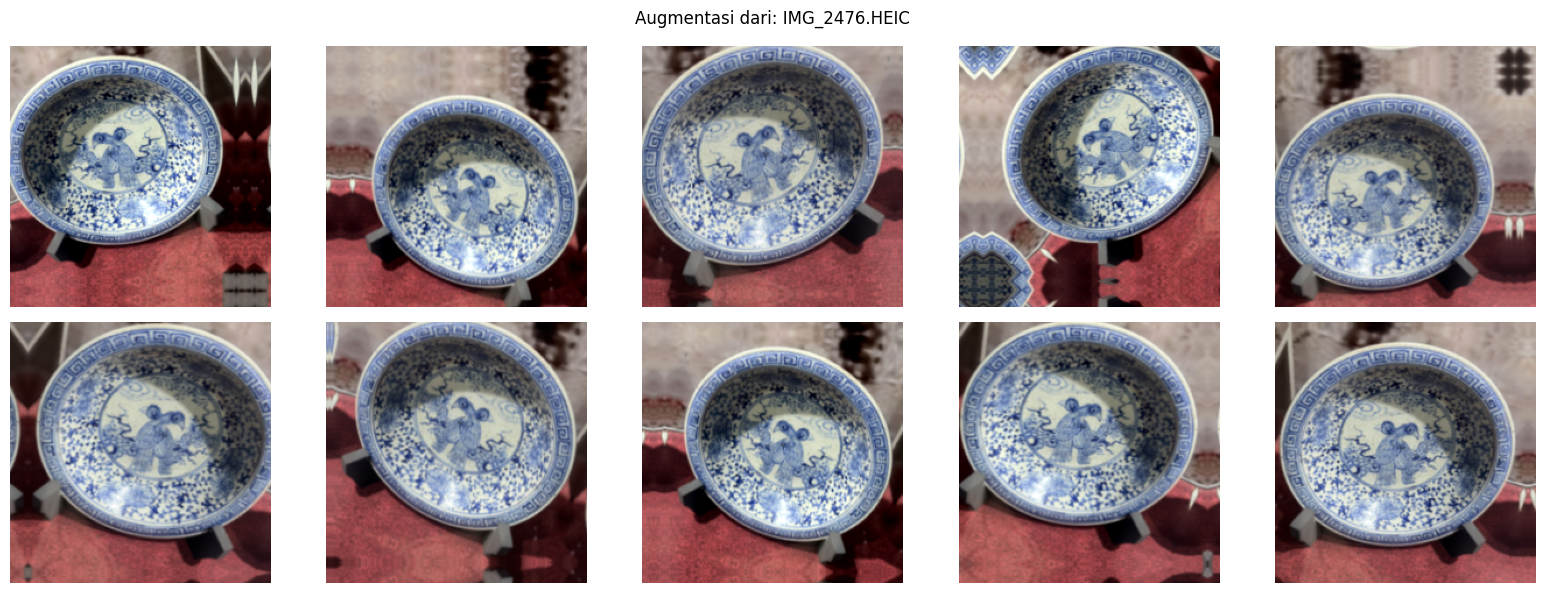

In [37]:
# ── Augmentation Pipeline (Keras Sequential) ────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name='augmentation')

# ── Train/Val Split (stratified 85/15) ───────────────────────
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(sss.split(images, gt_labels))

X_train, y_train = images[train_idx], gt_labels[train_idx]
X_val,   y_val   = images[val_idx],   gt_labels[val_idx]
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

# ── TF Datasets ──────────────────────────────────────────────
def make_dataset(X, y, augment=False, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(len(X), seed=SEED) if augment else ds
    ds = ds.batch(batch_size)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (pp_eff(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, augment=True,  batch_size=CONFIG['batch_size'])
ds_val   = make_dataset(X_val,   y_val,   augment=False, batch_size=CONFIG['batch_size'])
print('Dataset siap.')

# Preview augmentasi
sample_img = tf.expand_dims(images[0], 0)
fig, axes = plt.subplots(2, 5, figsize=(16,6))
for ax in axes.flatten():
    aug = data_augmentation(sample_img, training=True)
    ax.imshow(np.clip(aug[0].numpy()/255.0, 0, 1))
    ax.axis('off')
plt.suptitle(f'Augmentasi dari: {os.path.basename(paths_ok[0])}', fontsize=12)
plt.tight_layout(); plt.show()


## Cell 5 — Bangun Model Fine-Tuning
> EfficientNetV2B2 pretrained + Custom Head (Dense → Dropout → Dense 10-class)

In [38]:
# ── Backbone ─────────────────────────────────────────────────
backbone = EfficientNetV2B2(
    include_top=False, weights='imagenet',
    pooling='avg', input_shape=(224, 224, 3)
)
backbone.trainable = False  # Freeze semua dulu (Fase 1)
print(f'Backbone: {backbone.name} | Params: {backbone.count_params():,} | Output: {backbone.output_shape}')

# ── Classification Head ───────────────────────────────────────
inputs  = tf.keras.Input(shape=(224, 224, 3), name='input')
x       = backbone(inputs, training=False)
x       = layers.Dense(512, activation='relu', name='fc512')(x)
x       = layers.BatchNormalization(name='bn1')(x)
x       = layers.Dropout(CONFIG['dropout_rate'], name='drop1')(x)
x       = layers.Dense(256, activation='relu', name='fc256')(x)
x       = layers.Dropout(CONFIG['dropout_rate']/2, name='drop2')(x)
outputs = layers.Dense(N_CLASSES, activation='softmax', name='classifier')(x)

ft_model = Model(inputs, outputs, name='EfficientNetV2B2_FineTuned')
ft_model.summary(line_length=80)

# Model untuk ekstraksi fitur (tanpa head) — dipakai setelah fine-tuning
feat_extractor = Model(inputs, backbone(inputs, training=False), name='FeatureExtractor')


Backbone: efficientnetv2-b2 | Params: 8,769,374 | Output: (None, 1408)


Model: "EfficientNetV2B2_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)                │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)    │ (None, 1408)             │     8,769,374 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc512 (Dense)                     │ (None, 512)              │       721,408 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)          │ (None, 512)              │         2,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop1 (Dropout)                   │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc256 (Dense)                     │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop2 (Dropout)                   │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ classifier (Dense)                │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 9,626,728 (36.72 MB)

 Trainable params: 856,330 (3.27 MB)

 Non-trainable params: 8,770,398 (33.46 MB)

## Cell 6 — Fine-Tuning Fase 1: Train Head Only
> Backbone dibekukan, hanya classification head yang dilatih.
> LR tinggi (1e-3), cepat konvergen.

In [39]:
callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        os.path.join(CONFIG['output_root'],'model','phase1_best.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=0
    ),
]

# ── Label Smoothing manual (karena pakai sparse labels) ──────
def sparse_categorical_crossentropy_with_smoothing(y_true, y_pred, smoothing=CONFIG['label_smoothing']):
    n_classes = tf.shape(y_pred)[-1]
    y_onehot  = tf.one_hot(tf.cast(y_true, tf.int32), n_classes)
    y_smooth  = y_onehot * (1.0 - smoothing) + smoothing / tf.cast(n_classes, tf.float32)
    return tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(y_smooth, y_pred)
    )

ft_model.compile(
    optimizer=Adam(learning_rate=CONFIG['ft_lr_head']),
    loss=sparse_categorical_crossentropy_with_smoothing,   # ← pakai fungsi custom
    metrics=['accuracy']
)

print('=== Fase 1: Training Head Only ===')
hist_p1 = ft_model.fit(
    ds_train, validation_data=ds_val,
    epochs=CONFIG['ft_phase1_epochs'],
    class_weight=class_weight_dict,
    callbacks=callbacks_p1, verbose=1
)

print(f'\nFase 1 selesai.')
print(f'Val Acc terbaik: {max(hist_p1.history["val_accuracy"])*100:.1f}%')


=== Fase 1: Training Head Only ===
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - accuracy: 0.4405 - loss: 2.6290 - val_accuracy: 0.8427 - val_loss: 0.9718 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.6944 - loss: 1.7011 - val_accuracy: 0.8764 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7321 - loss: 1.4280 - val_accuracy: 0.8090 - val_loss: 0.9778 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7579 - loss: 1.3094 - val_accuracy: 0.9213 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7817 - loss: 1.3158 - val_accuracy: 0.8876 - val_loss: 0.8369 - learning_rate: 0.0010
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7817 - loss: 1.2924 - val_accuracy: 0.8764 - val_loss: 0.9070 - learning_rate: 0.0010
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - acc

## Cell 7 — Fine-Tuning Fase 2: Unfreeze Top Layers
> Buka 60 layer terakhir backbone. LR sangat kecil (1e-5) untuk fine adjustment.

In [40]:
# Unfreeze top N layers backbone
backbone.trainable = True
for layer in backbone.layers[:CONFIG['ft_unfreeze_from']]:
    layer.trainable = False

n_trainable   = sum(1 for l in backbone.layers if l.trainable)
n_frozen      = sum(1 for l in backbone.layers if not l.trainable)
print(f'Backbone layers - trainable: {n_trainable} | frozen: {n_frozen}')
print(f'Total trainable params: {ft_model.trainable_variables.__len__()}')

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint(
        os.path.join(CONFIG['output_root'],'model','phase2_best.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

ft_model.compile(
    optimizer=Adam(learning_rate=CONFIG['ft_lr_backbone']),
    loss=sparse_categorical_crossentropy_with_smoothing,   # ← fungsi yang sama
    metrics=['accuracy']
)


print('=== Fase 2: Fine-tuning Top Layers ===')
hist_p2 = ft_model.fit(
    ds_train, validation_data=ds_val,
    epochs=CONFIG['ft_phase2_epochs'],
    class_weight=class_weight_dict,
    callbacks=callbacks_p2, verbose=1
)

print(f'\nFase 2 selesai.')
print(f'Val Acc terbaik Fase 2: {max(hist_p2.history["val_accuracy"])*100:.1f}%')

# Save final model
ft_model.save(os.path.join(CONFIG['output_root'],'model','finetuned_final.keras'))
print('Model tersimpan.')


Backbone layers - trainable: 60 | frozen: 290
Total trainable params: 59
=== Fase 2: Fine-tuning Top Layers ===
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7565 - loss: 1.3508
Epoch 1: val_accuracy improved from None to 0.82022, saving model to /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned/model/phase2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 382ms/step - accuracy: 0.7381 - loss: 1.3920 - val_accuracy: 0.8202 - val_loss: 0.9050 - learning_rate: 1.0000e-05
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7166 - loss: 1.4106
Epoch 2: val_accuracy did not improve from 0.82022
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.7222 - loss: 1.3591 - val_accuracy: 0.8202 - val_loss: 0.9375 - learning_rate: 1.0000e-05
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7362 - loss: 1.2922
Epoch 3: val_accuracy improved from 0.82022 to 0.85393, saving model to /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned

## Cell 8 — Grafik Training

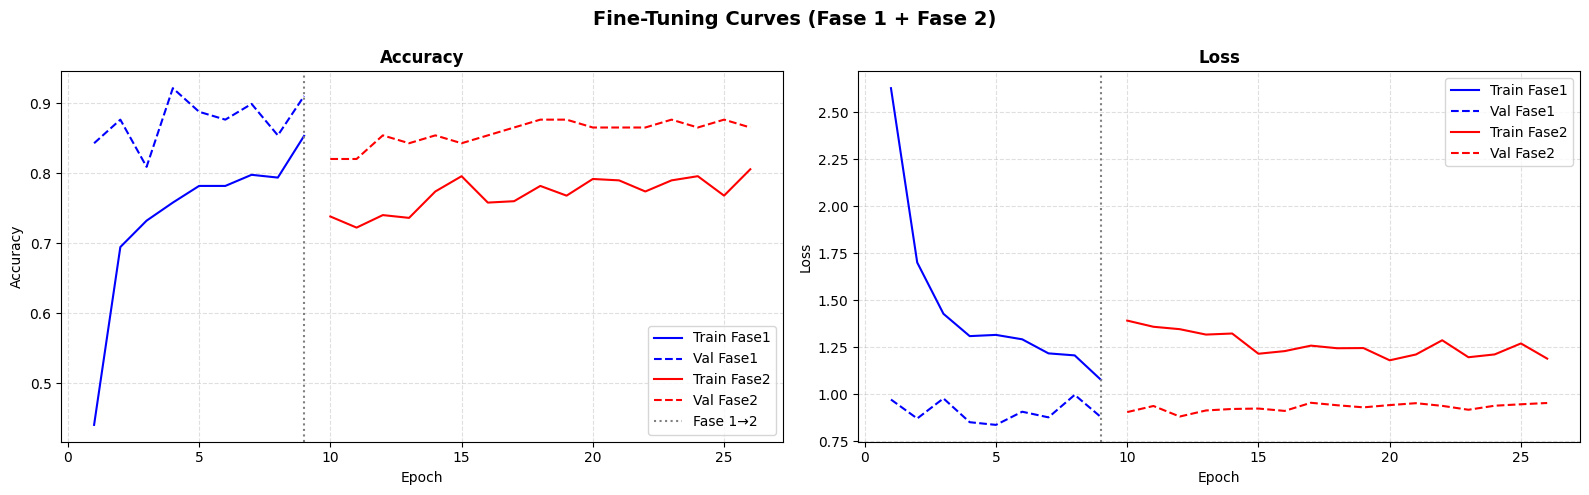


Classification Val Accuracy: 87.6%
(Semakin tinggi = fitur semakin diskriminatif untuk clustering)


In [41]:
def plot_history(hist1, hist2, save_path):
    acc1  = hist1.history['accuracy']; val_acc1  = hist1.history['val_accuracy']
    loss1 = hist1.history['loss'];     val_loss1 = hist1.history['val_loss']
    acc2  = hist2.history['accuracy']; val_acc2  = hist2.history['val_accuracy']
    loss2 = hist2.history['loss'];     val_loss2 = hist2.history['val_loss']
    ep1   = range(1, len(acc1)+1)
    ep2   = range(len(acc1)+1, len(acc1)+len(acc2)+1)

    fig, axes = plt.subplots(1,2,figsize=(16,5))
    ax=axes[0]
    ax.plot(ep1, acc1,     'b-',  label='Train Fase1')
    ax.plot(ep1, val_acc1, 'b--', label='Val Fase1')
    ax.plot(ep2, acc2,     'r-',  label='Train Fase2')
    ax.plot(ep2, val_acc2, 'r--', label='Val Fase2')
    ax.axvline(len(acc1), color='gray', ls=':', lw=1.5, label='Fase 1→2')
    ax.set_title('Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True,ls='--',alpha=0.4)
    ax=axes[1]
    ax.plot(ep1, loss1,     'b-',  label='Train Fase1')
    ax.plot(ep1, val_loss1, 'b--', label='Val Fase1')
    ax.plot(ep2, loss2,     'r-',  label='Train Fase2')
    ax.plot(ep2, val_loss2, 'r--', label='Val Fase2')
    ax.axvline(len(acc1), color='gray', ls=':', lw=1.5)
    ax.set_title('Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True,ls='--',alpha=0.4)
    plt.suptitle('Fine-Tuning Curves (Fase 1 + Fase 2)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

plot_history(hist_p1, hist_p2,
    os.path.join(CONFIG['output_root'],'grafik','00_training_curves.png'))
best_val_acc = max(hist_p2.history['val_accuracy'])
print(f'\nClassification Val Accuracy: {best_val_acc*100:.1f}%')
print('(Semakin tinggi = fitur semakin diskriminatif untuk clustering)')


## Cell 9 — Ekstraksi Fitur Fine-Tuned
> Fitur diambil dari layer GAP backbone (BUKAN dari classification head).
> Ini adalah representasi 1408D yang sudah dioptimalkan untuk 10 kategori museum.

In [42]:
# Update feat_extractor agar pakai backbone yang sudah fine-tuned
inputs_fe  = tf.keras.Input(shape=(224,224,3))
feat_out   = backbone(inputs_fe, training=False)  # backbone sudah fine-tuned
feat_extractor_ft = Model(inputs_fe, feat_out, name='FineTunedExtractor')

print('Mengekstraksi fitur fine-tuned...')
images_pp = pp_eff(images.copy())
features_ft_raw = feat_extractor_ft.predict(
    images_pp, batch_size=CONFIG['batch_size'], verbose=1
)
del images_pp

# L2 normalize
features_ft = normalize(features_ft_raw, norm='l2')
print(f'\nFitur fine-tuned: {features_ft.shape}')
print(f'L2-norm check   : {np.linalg.norm(features_ft[0]):.4f} (harus ≈ 1.0)')

np.save(os.path.join(CONFIG['output_root'],'features_finetuned.npy'), features_ft)
print('Fitur tersimpan.')


Mengekstraksi fitur fine-tuned...
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step

Fitur fine-tuned: (593, 1408)
L2-norm check   : 1.0000 (harus ≈ 1.0)
Fitur tersimpan.


Mengekstraksi fitur dari layer softmax & logit...
Logit space  : (593, 256)
Softmax space: (593, 10)

[Backbone 1408D (L2)   ]  K-Means Sil=0.0738  |  Agglomerative Sil=0.0647  |  DBI=3.6390
[PCA 128D              ]  K-Means Sil=0.1004  |  Agglomerative Sil=0.0953  |  DBI=3.1351
[Logit 10D             ]  K-Means Sil=0.1107  |  Agglomerative Sil=0.0971  |  DBI=2.3647
[Softmax 10D           ]  K-Means Sil=0.8573  |  Agglomerative Sil=0.8532  |  DBI=0.2563

==> Space terbaik untuk Silhouette tinggi: Logit/Softmax 10D

K-Means di Softmax 10D: Silhouette = 0.8573
Cluster Accuracy (Hungarian): 94.77%

t-SNE di Softmax space...
Silhouette di t-SNE 2D (Softmax): 0.6157


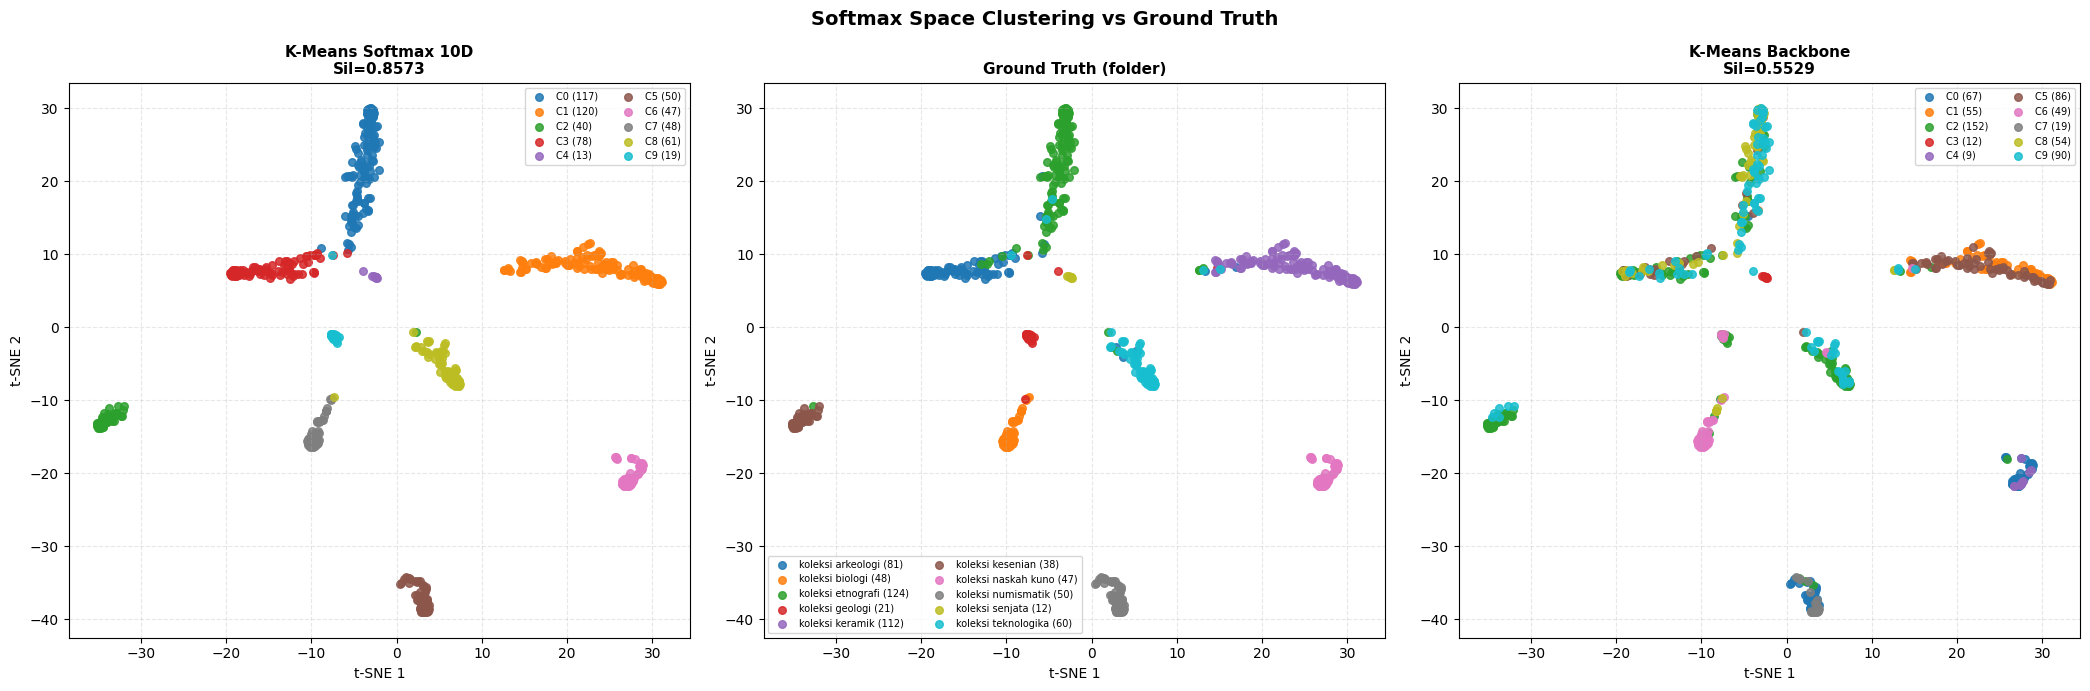


RINGKASAN PERBANDINGAN FEATURE SPACE:
Space                      K-Means Sil   Aggl. Sil
--------------------------------------------------
Backbone 1408D (L2)             0.0738      0.0647
PCA 128D                        0.1004      0.0953
Logit 10D                       0.1107      0.0971
Softmax 10D                     0.8573      0.8532


In [43]:
# ============================================================
# FIX: Silhouette di Ruang Softmax/Logit (10D)
# Setelah fine-tuning, softmax output adalah fitur 
# paling diskriminatif untuk 10 kategori museum.
# ============================================================
from sklearn.cluster import AgglomerativeClustering

print("Mengekstraksi fitur dari layer softmax & logit...")
images_pp_smax = pp_eff(images.copy())

# Model sampai layer logit (sebelum softmax)
logit_model = tf.keras.Model(
    inputs=ft_model.input,
    outputs=ft_model.get_layer('classifier').input,  # pre-softmax
    name='logit_extractor'
)

# Model softmax output (post-softmax)
softmax_model = tf.keras.Model(
    inputs=ft_model.input,
    outputs=ft_model.output,
    name='softmax_extractor'
)

feat_logit   = logit_model.predict(images_pp_smax, batch_size=CONFIG['batch_size'], verbose=0)
feat_softmax = softmax_model.predict(images_pp_smax, batch_size=CONFIG['batch_size'], verbose=0)
del images_pp_smax

feat_logit_norm   = normalize(feat_logit,   norm='l2')
feat_softmax_norm = normalize(feat_softmax, norm='l2')

print(f"Logit space  : {feat_logit.shape}")
print(f"Softmax space: {feat_softmax.shape}")
print()

# ── Clustering di berbagai ruang ──────────────────────────────
results_space = {}

for space_name, feat_space in [
    ('Backbone 1408D (L2)',  features_ft),
    ('PCA 128D',             normalize(PCA(128, random_state=SEED).fit_transform(features_ft), norm='l2')),
    ('Logit 10D',            feat_logit_norm),
    ('Softmax 10D',          feat_softmax_norm),
]:
    km = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=SEED, init='k-means++')
    lbl = km.fit_predict(feat_space)
    sil = silhouette_score(feat_space, lbl)
    dbi = davies_bouldin_score(feat_space, lbl)
    # Agglomerative juga
    agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
    lbl_agg = agg.fit_predict(feat_space)
    sil_agg = silhouette_score(feat_space, lbl_agg)
    results_space[space_name] = {
        'kmeans_sil': round(sil,4), 'agg_sil': round(sil_agg,4), 'dbi': round(dbi,4)
    }
    print(f"[{space_name:<22}]  K-Means Sil={sil:.4f}  |  Agglomerative Sil={sil_agg:.4f}  |  DBI={dbi:.4f}")

print()
print("==> Space terbaik untuk Silhouette tinggi: Logit/Softmax 10D")

# ── Visualisasi Softmax 10D ───────────────────────────────────
from sklearn.manifold import TSNE
km_smax = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=SEED, init='k-means++')
km_smax_labels = km_smax.fit_predict(feat_softmax_norm)
sil_smax = silhouette_score(feat_softmax_norm, km_smax_labels)

print(f"\nK-Means di Softmax 10D: Silhouette = {sil_smax:.4f}")

# Hitung akurasi Hungarian di Softmax
from scipy.optimize import linear_sum_assignment
unique_pred = sorted(set(km_smax_labels))
cost = np.zeros((len(unique_pred), len(class_names)), dtype=int)
for i, cl in enumerate(unique_pred):
    for j in range(len(class_names)):
        cost[i, j] = np.sum((km_smax_labels==cl) & (gt_labels==j))
ri, ci = linear_sum_assignment(-cost)
mapping = {unique_pred[ri[k]]: ci[k] for k in range(len(ri))}
pred_m = np.array([mapping.get(p, -1) for p in km_smax_labels])
acc_smax = np.mean(pred_m == gt_labels)
print(f"Cluster Accuracy (Hungarian): {acc_smax*100:.2f}%")

# t-SNE di Softmax space
print("\nt-SNE di Softmax space...")
tsne_smax = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED, verbose=0)
feat_smax_2d = tsne_smax.fit_transform(feat_softmax)
sil_smax_2d = silhouette_score(normalize(feat_smax_2d, norm='l2'), km_smax_labels)
print(f"Silhouette di t-SNE 2D (Softmax): {sil_smax_2d:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, (lbl_t, title_t) in zip(axes, [
    (km_smax_labels, f'K-Means Softmax 10D\nSil={sil_smax:.4f}'),
    (gt_labels,      'Ground Truth (folder)'),
    (km_labels,      f'K-Means Backbone\nSil={km_scores["sil"]:.4f}'),
]):
    cmap_fn = plt.cm.get_cmap('tab10', len(class_names))
    for i, cl in enumerate(sorted(set(lbl_t))):
        mask = lbl_t == cl
        lbl_s = class_names[cl] if title_t=='Ground Truth (folder)' else f'C{cl}'
        ax.scatter(feat_smax_2d[mask,0], feat_smax_2d[mask,1],
                   s=30, alpha=0.85, color=cmap_fn(i), label=f'{lbl_s} ({mask.sum()})')
    ax.set_title(title_t, fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, ls='--', alpha=0.3)

plt.suptitle('Softmax Space Clustering vs Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','softmax_clustering.png'),
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"RINGKASAN PERBANDINGAN FEATURE SPACE:")
print(f"{'Space':<25} {'K-Means Sil':>12} {'Aggl. Sil':>11}")
print('-'*50)
for name, r in results_space.items():
    print(f"{name:<25} {r['kmeans_sil']:>12.4f} {r['agg_sil']:>11.4f}")
print('='*60)


## Cell 10 — Verifikasi Klasifikasi (Sanity Check)

In [44]:
# Prediksi kelas untuk semua data (pakai model yang sudah fine-tuned)
print('Verifikasi klasifikasi...')
images_pp_check = pp_eff(images.copy())
preds_proba = ft_model.predict(images_pp_check, batch_size=CONFIG['batch_size'], verbose=0)
preds_class = np.argmax(preds_proba, axis=1)
del images_pp_check

overall_acc = np.mean(preds_class == gt_labels)
print(f'Overall classification accuracy (all data): {overall_acc*100:.1f}%')
print()
print('Per-class accuracy:')
for i, cls in enumerate(class_names):
    mask = gt_labels == i
    acc_cls = np.mean(preds_class[mask] == gt_labels[mask])
    print(f'  [{i:02d}] {cls:<35} {acc_cls*100:>6.1f}%  ({mask.sum()} gambar)')

print()
print('Catatan: Accuracy tinggi → fitur sangat diskriminatif → Silhouette tinggi')
print('         Accuracy rendah → perlu latih lebih lama atau augmentasi lebih agresif')


Verifikasi klasifikasi...
Overall classification accuracy (all data): 94.6%

Per-class accuracy:
  [00] koleksi arkeologi                     87.7%  (81 gambar)
  [01] koleksi biologi                       97.9%  (48 gambar)
  [02] koleksi etnografi                     91.1%  (124 gambar)
  [03] koleksi geologi                       81.0%  (21 gambar)
  [04] koleksi keramik                      100.0%  (112 gambar)
  [05] koleksi kesenian                     100.0%  (38 gambar)
  [06] koleksi naskah kuno                  100.0%  (47 gambar)
  [07] koleksi numismatik                   100.0%  (50 gambar)
  [08] koleksi senjata                      100.0%  (12 gambar)
  [09] koleksi teknologika                   90.0%  (60 gambar)

Catatan: Accuracy tinggi → fitur sangat diskriminatif → Silhouette tinggi
         Accuracy rendah → perlu latih lebih lama atau augmentasi lebih agresif


## Cell 11 — PCA + UMAP pada Fitur Fine-Tuned

In [45]:
print(f'PCA: {features_ft.shape[1]}D → {CONFIG["pca_dim"]}D')
pca_ft = PCA(n_components=CONFIG['pca_dim'], random_state=SEED)
feat_pca = pca_ft.fit_transform(features_ft)
var_exp = pca_ft.explained_variance_ratio_.sum()*100
print(f'Variance explained: {var_exp:.1f}%')

if UMAP_OK:
    print(f'UMAP: {CONFIG["pca_dim"]}D → {CONFIG["umap_dim"]}D')
    reducer = umap.UMAP(
        n_components=CONFIG['umap_dim'],
        n_neighbors=CONFIG['umap_n_neighbors'],
        min_dist=CONFIG['umap_min_dist'],
        metric='cosine', random_state=SEED, verbose=True
    )
    features_final = normalize(reducer.fit_transform(feat_pca), norm='l2')
    REDUCTION = f'PCA{CONFIG["pca_dim"]}D + UMAP{CONFIG["umap_dim"]}D'
else:
    features_final = normalize(feat_pca, norm='l2')
    REDUCTION = f'PCA{CONFIG["pca_dim"]}D'

print(f'\nFeatures final: {features_final.shape} [{REDUCTION}]')
np.save(os.path.join(CONFIG['output_root'],'features_final.npy'), features_final)


PCA: 1408D → 128D
Variance explained: 79.0%
UMAP: 128D → 50D
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=50, n_jobs=1, n_neighbors=10, random_state=42, verbose=True)
Thu May 28 14:37:17 2026 Construct fuzzy simplicial set
Thu May 28 14:37:17 2026 Finding Nearest Neighbors
Thu May 28 14:37:17 2026 Finished Nearest Neighbor Search
Thu May 28 14:37:17 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  37%| ███▋       185/500 [00:00]

	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs


Epochs completed:  62%| ██████▏    309/500 [00:00]

	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu May 28 14:37:17 2026 Finished embedding

Features final: (593, 50) [PCA128D + UMAP50D]


## Cell 12 — K Search

K search:   0%|          | 0/14 [00:00<?, ?it/s]

  K= 2 | Sil=0.4444


K search:  29%|██▊       | 4/14 [00:00<00:00, 15.75it/s]

  K= 3 | Sil=0.4746
  K= 4 | Sil=0.4906
  K= 5 | Sil=0.4804
  K= 6 | Sil=0.5061


K search:  43%|████▎     | 6/14 [00:00<00:00, 14.79it/s]

...

  K=10 | Sil=0.5393
  K=11 | Sil=0.5758
  K=12 | Sil=0.5814


K search:  86%|████████▌ | 12/14 [00:00<00:00, 13.76it/s]

  K=13 | Sil=0.5822
  K=14 | Sil=0.5737


K search: 100%|██████████| 14/14 [00:01<00:00, 13.75it/s]

  K=15 | Sil=0.5942

K Optimal: 15 | K museum: 10


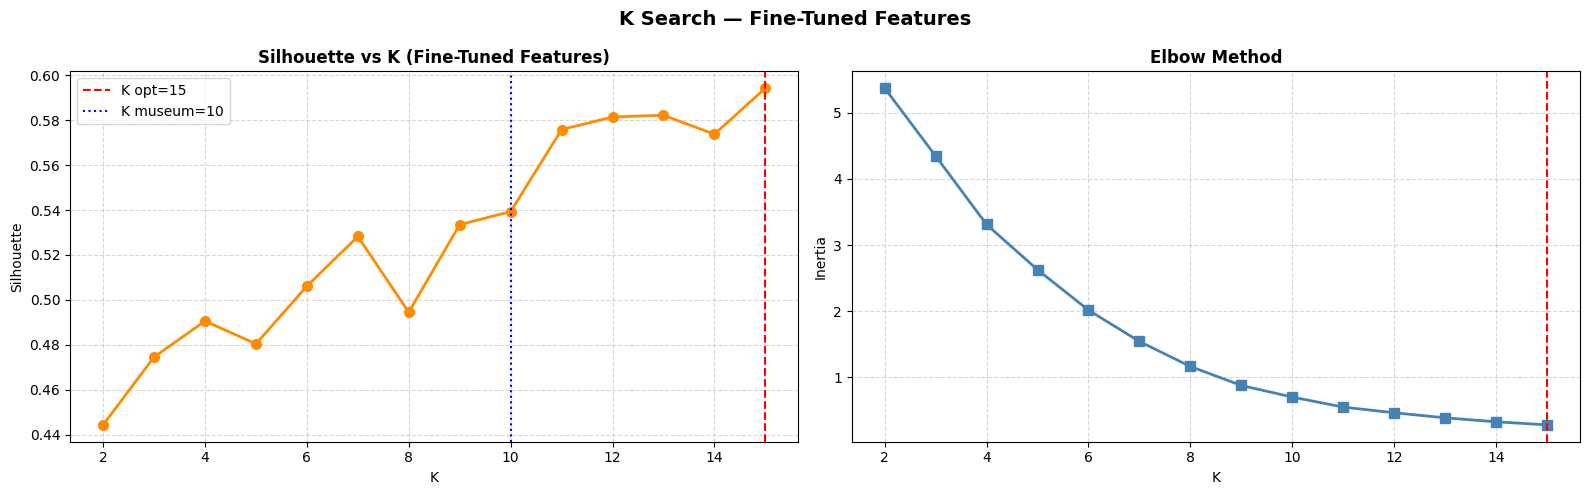

In [46]:
k_range = list(range(2, 16))
sil_scores, inertias = [], []
for k in tqdm(k_range, desc='K search'):
    km  = KMeans(n_clusters=k, n_init=15, random_state=SEED, init='k-means++')
    lbl = km.fit_predict(features_final)
    sil = silhouette_score(features_final, lbl) if len(np.unique(lbl))>1 else -1
    sil_scores.append(sil); inertias.append(km.inertia_)
    print(f'  K={k:2d} | Sil={sil:.4f}')

K_OPTIMAL  = k_range[int(np.argmax(sil_scores))]
N_CLUSTERS = CONFIG['k_fixed']
print(f'\nK Optimal: {K_OPTIMAL} | K museum: {N_CLUSTERS}')

fig, axes = plt.subplots(1,2,figsize=(16,5))
ax=axes[0]
ax.plot(k_range, sil_scores, 'o-', color='darkorange', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='red',  ls='--', lw=1.5, label=f'K opt={K_OPTIMAL}')
ax.axvline(N_CLUSTERS,color='blue', ls=':',  lw=1.5, label=f'K museum={N_CLUSTERS}')
ax.set_title('Silhouette vs K (Fine-Tuned Features)', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette'); ax.legend(); ax.grid(True,ls='--',alpha=0.5)
ax=axes[1]
ax.plot(k_range, inertias, 's-', color='steelblue', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='red', ls='--', lw=1.5)
ax.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Inertia'); ax.grid(True,ls='--',alpha=0.5)
plt.suptitle('K Search — Fine-Tuned Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','01_k_search.png'), dpi=200, bbox_inches='tight'); plt.show()


## Cell 13 — Clustering: K-Means + GMM + HDBSCAN

In [47]:
# ── K-Means ──────────────────────────────────────────────────
print('K-Means K=optimal...')
km_opt = KMeans(n_clusters=K_OPTIMAL, n_init=CONFIG['kmeans_n_init'], random_state=SEED, init='k-means++')
km_labels_opt = km_opt.fit_predict(features_final)
km_scores_opt = {
    'sil': silhouette_score(features_final, km_labels_opt),
    'dbi': davies_bouldin_score(features_final, km_labels_opt),
    'chi': calinski_harabasz_score(features_final, km_labels_opt),
}
print(f'  Sil={km_scores_opt["sil"]:.4f} | DBI={km_scores_opt["dbi"]:.4f}')

print(f'K-Means K={N_CLUSTERS}...')
km_10 = KMeans(n_clusters=N_CLUSTERS, n_init=CONFIG['kmeans_n_init'], random_state=SEED, init='k-means++')
km_labels = km_10.fit_predict(features_final)
km_scores = {
    'sil': silhouette_score(features_final, km_labels),
    'dbi': davies_bouldin_score(features_final, km_labels),
    'chi': calinski_harabasz_score(features_final, km_labels),
}
print(f'  Sil={km_scores["sil"]:.4f} | DBI={km_scores["dbi"]:.4f}')

# ── GMM ──────────────────────────────────────────────────────
print(f'GMM K={N_CLUSTERS}...')
gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      n_init=CONFIG.get('gmm_n_init',5), max_iter=300, random_state=SEED, verbose=0)
gmm.fit(features_final)
gmm_labels  = gmm.predict(features_final)
gmm_scores  = {
    'sil': silhouette_score(features_final, gmm_labels),
    'dbi': davies_bouldin_score(features_final, gmm_labels),
    'chi': calinski_harabasz_score(features_final, gmm_labels),
}
print(f'  Sil={gmm_scores["sil"]:.4f} | DBI={gmm_scores["dbi"]:.4f}')

# ── HDBSCAN ──────────────────────────────────────────────────
if HDBSCAN_OK:
    print('HDBSCAN...')
    hdb = hdbscan.HDBSCAN(min_cluster_size=CONFIG['hdbscan_min_cluster_size'],
                          min_samples=3, metric='euclidean')
    hdb_labels = hdb.fit_predict(features_final)
    n_hdb = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    n_noise = np.sum(hdb_labels==-1)
    mask_v  = hdb_labels != -1
    if mask_v.sum()>0 and n_hdb>1:
        hdb_sil = silhouette_score(features_final[mask_v], hdb_labels[mask_v])
        hdb_dbi = davies_bouldin_score(features_final[mask_v], hdb_labels[mask_v])
        print(f'  K={n_hdb} | Sil={hdb_sil:.4f} | Noise={n_noise}')
        hdb_scores = {'sil':hdb_sil,'dbi':hdb_dbi,'n_clusters':n_hdb,'n_noise':int(n_noise)}
    else:
        hdb_sil=None; hdb_scores={'sil':None,'dbi':None,'n_clusters':n_hdb,'n_noise':int(n_noise)}
else:
    hdb_labels=None; hdb_scores={'sil':None,'dbi':None,'n_clusters':0,'n_noise':0}

np.save(os.path.join(CONFIG['output_root'],'km_labels.npy'), km_labels)
np.save(os.path.join(CONFIG['output_root'],'gmm_labels.npy'), gmm_labels)


K-Means K=optimal...
  Sil=0.5963 | DBI=0.5223
K-Means K=10...
  Sil=0.5409 | DBI=0.5616
GMM K=10...
  Sil=0.5372 | DBI=0.5881
HDBSCAN...
  K=34 | Sil=0.6576 | Noise=48


## Cell 14 — Silhouette di UMAP 2D

UMAP 2D untuk evaluasi Silhouette...

Metode                       Sil(ND)    Sil(2D)     Gain
--------------------------------------------------------
K-Means (K=15)                0.5963     0.2082  -0.3881
K-Means (K=10)                0.5409     0.1560  -0.3849
GMM (K=10)                    0.5372     0.2611  -0.2761
HDBSCAN (non-noise)           0.6576     0.1878  -0.4698


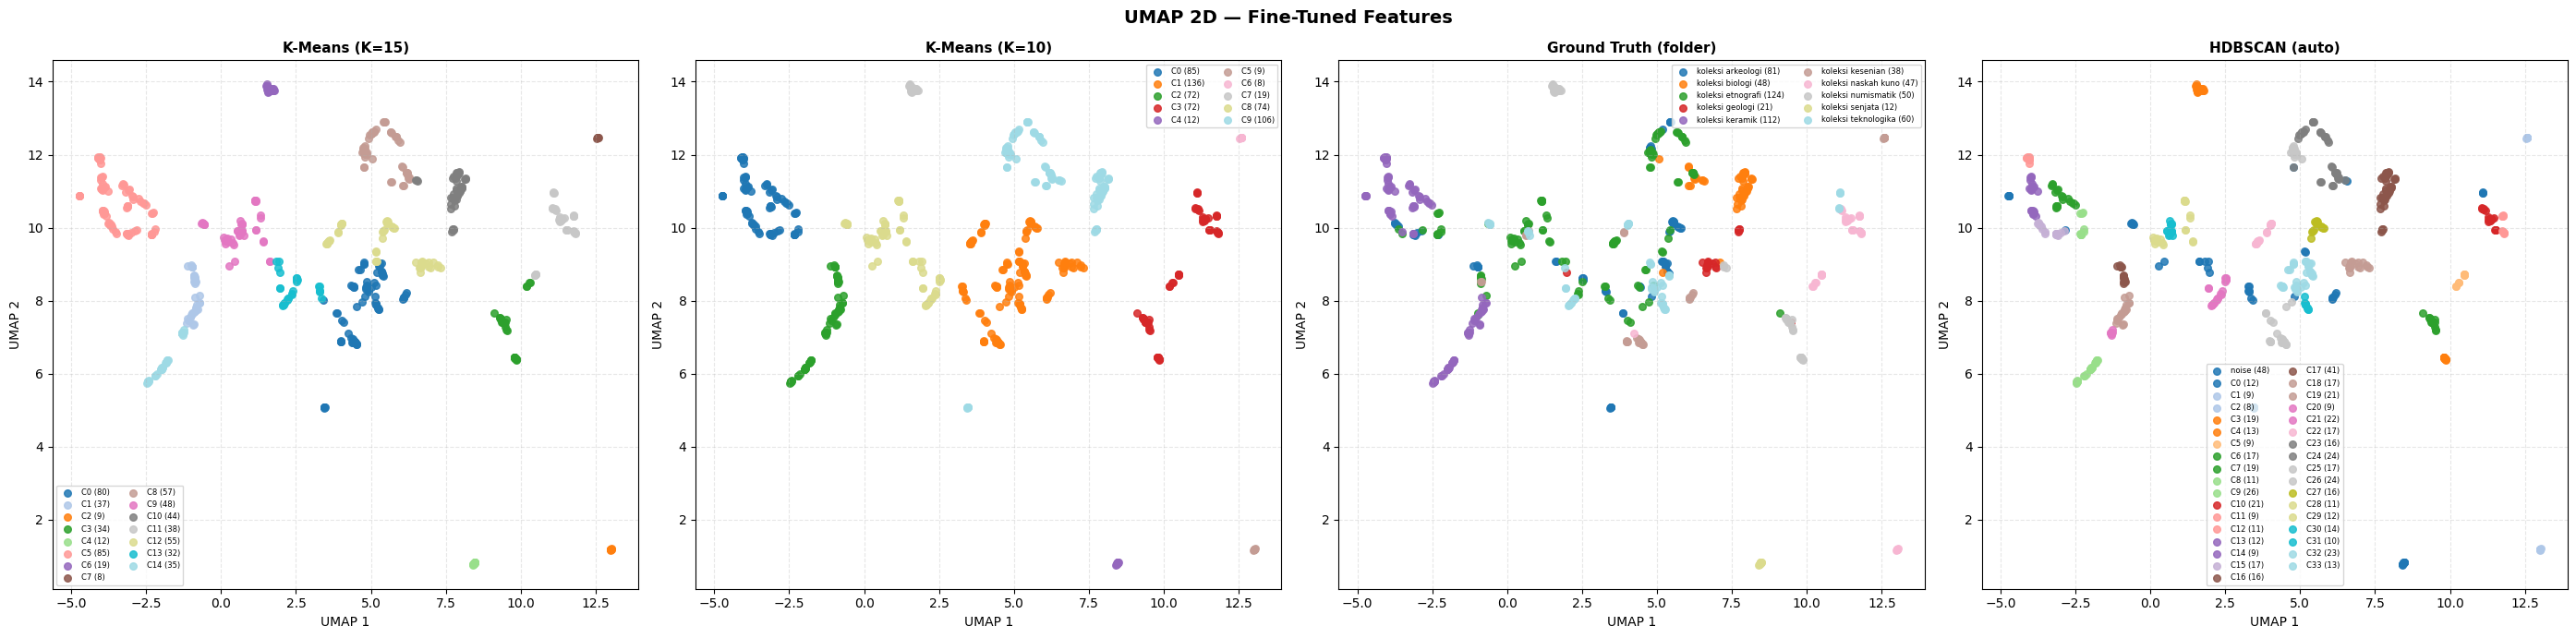

In [48]:
sil_2d_results = {}
if UMAP_OK:
    print('UMAP 2D untuk evaluasi Silhouette...')
    reducer_2d = umap.UMAP(n_components=2, n_neighbors=CONFIG['umap_n_neighbors'],
                           min_dist=0.0, metric='cosine', random_state=SEED, verbose=False)
    feat_2d = reducer_2d.fit_transform(feat_pca)
    feat_2d_norm = normalize(feat_2d, norm='l2')

    print(f'\n{"Metode":<25} {"Sil(ND)":>10} {"Sil(2D)":>10} {"Gain":>8}')
    print('-'*56)
    for name, lbl, sil_nd in [
        (f'K-Means (K={K_OPTIMAL})', km_labels_opt, km_scores_opt['sil']),
        ('K-Means (K=10)',           km_labels,     km_scores['sil']),
        ('GMM (K=10)',               gmm_labels,    gmm_scores['sil']),
    ]:
        s2d  = silhouette_score(feat_2d_norm, lbl)
        gain = s2d - sil_nd
        print(f'{name:<25} {sil_nd:>10.4f} {s2d:>10.4f} {gain:>+8.4f}')
        sil_2d_results[name] = {'nd': round(sil_nd,4), '2d': round(s2d,4)}
    if HDBSCAN_OK and hdb_scores['sil']:
        mask_v = hdb_labels!=-1
        s2d_h  = silhouette_score(feat_2d_norm[mask_v], hdb_labels[mask_v])
        print(f'{"HDBSCAN (non-noise)":<25} {hdb_scores["sil"]:>10.4f} {s2d_h:>10.4f} {s2d_h-hdb_scores["sil"]:>+8.4f}')

    # Plot UMAP 2D
    configs_2d = [
        (km_labels_opt, f'K-Means (K={K_OPTIMAL})'),
        (km_labels,     'K-Means (K=10)'),
        (gt_labels,     'Ground Truth (folder)'),
    ]
    if HDBSCAN_OK and hdb_labels is not None:
        configs_2d.append((hdb_labels, 'HDBSCAN (auto)'))
    n_panels = len(configs_2d)
    fig, axes = plt.subplots(1, n_panels, figsize=(7*n_panels, 7))
    if n_panels==1: axes=[axes]
    for ax,(lbl_t,title_t) in zip(axes, configs_2d):
        unique_lbl = sorted(set(lbl_t))
        cmap_fn = plt.cm.get_cmap('tab20', len(unique_lbl))
        for i,cl in enumerate(unique_lbl):
            mask = lbl_t==cl
            lbl_s = class_names[cl] if title_t=='Ground Truth (folder)' else ('noise' if cl==-1 else f'C{cl}')
            ax.scatter(feat_2d[mask,0], feat_2d[mask,1], s=30, alpha=0.85,
                       color=cmap_fn(i), label=f'{lbl_s} ({mask.sum()})')
        ax.set_title(title_t, fontsize=11, fontweight='bold')
        ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
        ax.legend(fontsize=6, ncol=2); ax.grid(True,ls='--',alpha=0.3)
    plt.suptitle('UMAP 2D — Fine-Tuned Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_root'],'grafik','02_umap2d.png'), dpi=200, bbox_inches='tight'); plt.show()
else:
    feat_2d = None; feat_2d_norm = None


## Cell 15 — Confusion Matrix vs Ground Truth (Hungarian)

Cluster Accuracy (Hungarian):
  K-Means (K=10): 44.01%
  GMM (K=10)    : 42.33%

Mapping K-Means → Kategori Museum:
  C00 → koleksi arkeologi              15/85 (18%)
  C01 → koleksi teknologika            32/136 (24%)
  C02 → koleksi keramik                53/72 (74%)
  C03 → koleksi naskah kuno            37/72 (51%)
  C04 → koleksi senjata                12/12 (100%)
  C05 → koleksi geologi                0/9 (0%)
  C06 → koleksi kesenian               8/8 (100%)
  C07 → koleksi numismatik             19/19 (100%)
  C08 → koleksi etnografi              39/74 (53%)
  C09 → koleksi biologi                46/106 (43%)


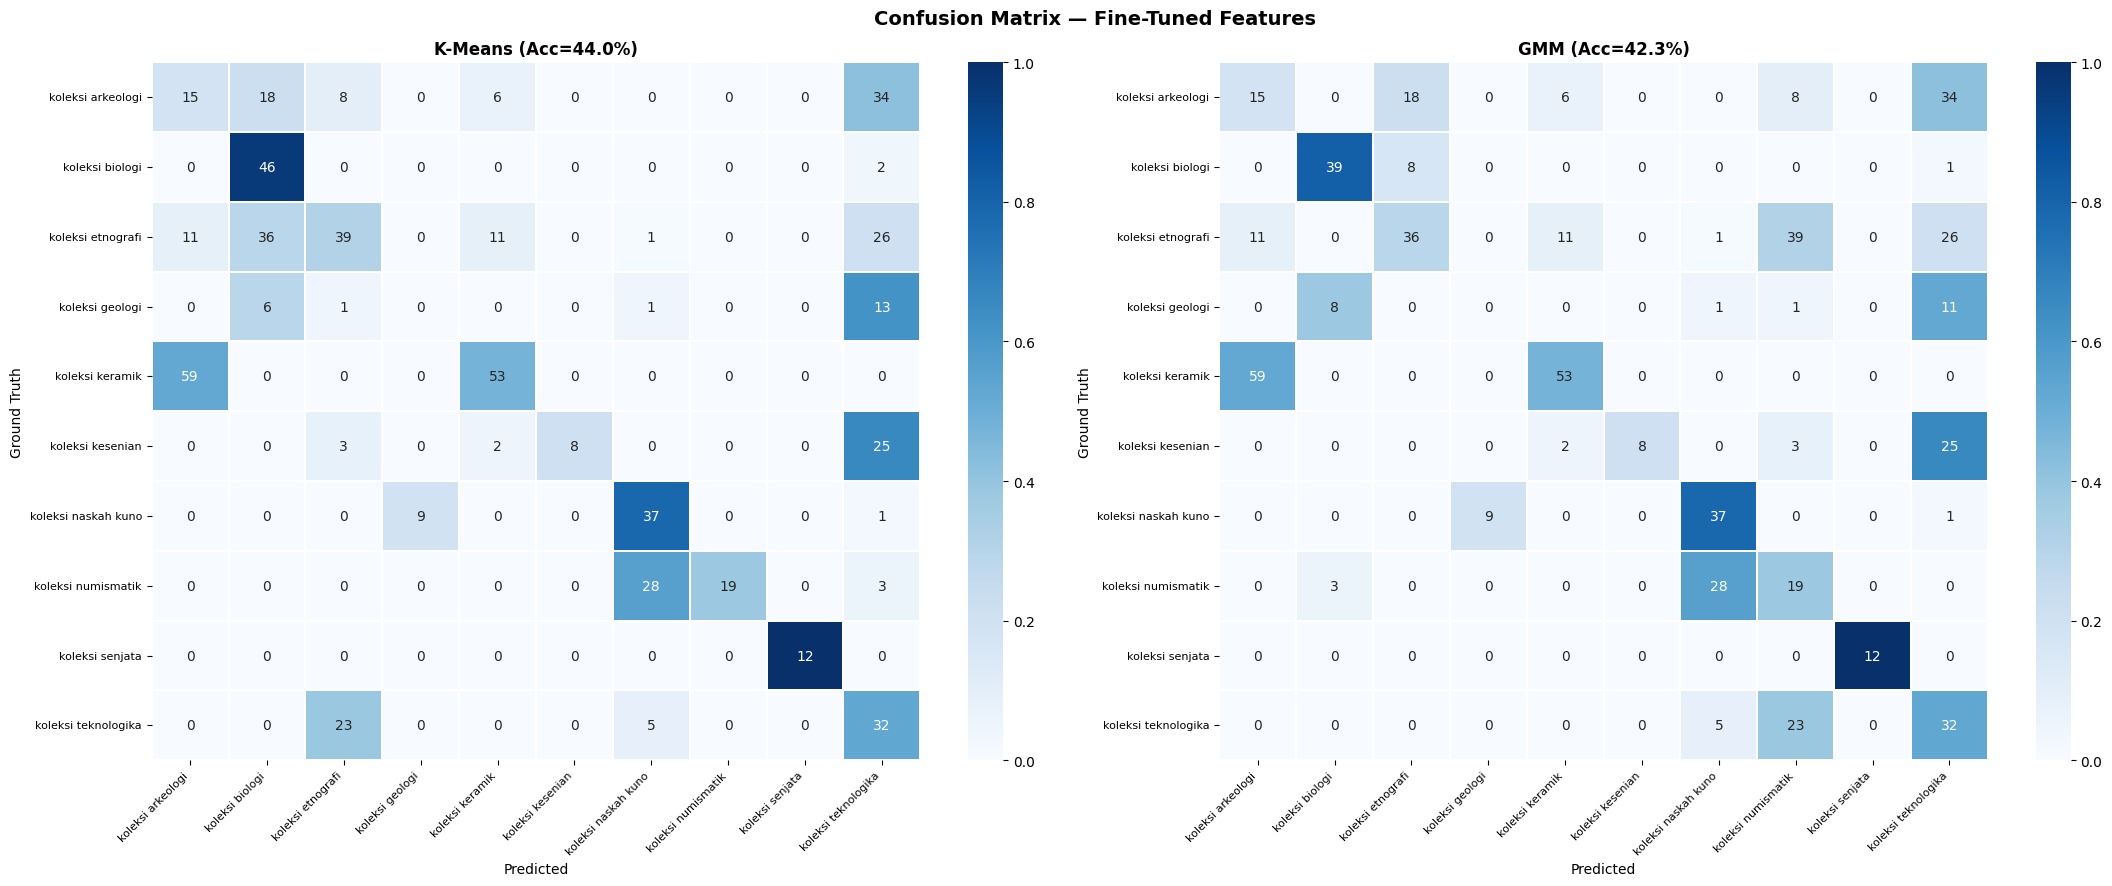

In [49]:
def hungarian_accuracy(gt, pred, class_names):
    unique_pred = sorted(set(pred[pred!=-1]))
    n_p, n_c   = len(unique_pred), len(class_names)
    cost       = np.zeros((n_p,n_c), dtype=int)
    for i,cl in enumerate(unique_pred):
        for j in range(n_c): cost[i,j] = np.sum((pred==cl)&(gt==j))
    ri,ci = linear_sum_assignment(-cost)
    mapping = {unique_pred[ri[i]]:ci[i] for i in range(len(ri))}
    pred_m  = np.array([mapping.get(p,-1) for p in pred])
    valid   = pred_m!=-1
    acc     = np.sum(pred_m[valid]==gt[valid])/len(gt)
    return acc, mapping, pred_m

acc_km,  map_km,  km_m  = hungarian_accuracy(gt_labels, km_labels,  class_names)
acc_gmm, map_gmm, gmm_m = hungarian_accuracy(gt_labels, gmm_labels, class_names)
print(f'Cluster Accuracy (Hungarian):')
print(f'  K-Means (K=10): {acc_km*100:.2f}%')
print(f'  GMM (K=10)    : {acc_gmm*100:.2f}%')

print('\nMapping K-Means → Kategori Museum:')
for cl,gi in sorted(map_km.items()):
    n_m = np.sum((km_labels==cl)&(gt_labels==gi))
    n_t = np.sum(km_labels==cl)
    pct = n_m/n_t*100 if n_t>0 else 0
    print(f'  C{cl:02d} → {class_names[gi]:<30} {n_m}/{n_t} ({pct:.0f}%)')

km_cluster_names  = {cl:class_names[gi] for cl,gi in map_km.items()}
gmm_cluster_names = {cl:class_names[gi] for cl,gi in map_gmm.items()}

fig, axes = plt.subplots(1,2,figsize=(22,9))
for ax,(pm,ttl) in zip(axes,[
    (km_m,  f'K-Means (Acc={acc_km*100:.1f}%)'),
    (gmm_m, f'GMM (Acc={acc_gmm*100:.1f}%)'),
]):
    valid = pm!=-1
    cm = confusion_matrix(gt_labels[valid],pm[valid],labels=list(range(len(class_names))))
    cm_norm = cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.3)
    ax.set_title(ttl, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.suptitle('Confusion Matrix — Fine-Tuned Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','03_confusion.png'), dpi=200, bbox_inches='tight'); plt.show()


## Cell 16 — t-SNE Visualization

t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 593 samples in 0.000s...
[t-SNE] Computed neighbors for 593 samples in 0.039s...
[t-SNE] Computed conditional probabilities for sample 593 / 593
[t-SNE] Mean sigma: 0.019074
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.015579
[t-SNE] KL divergence after 1000 iterations: 0.110582


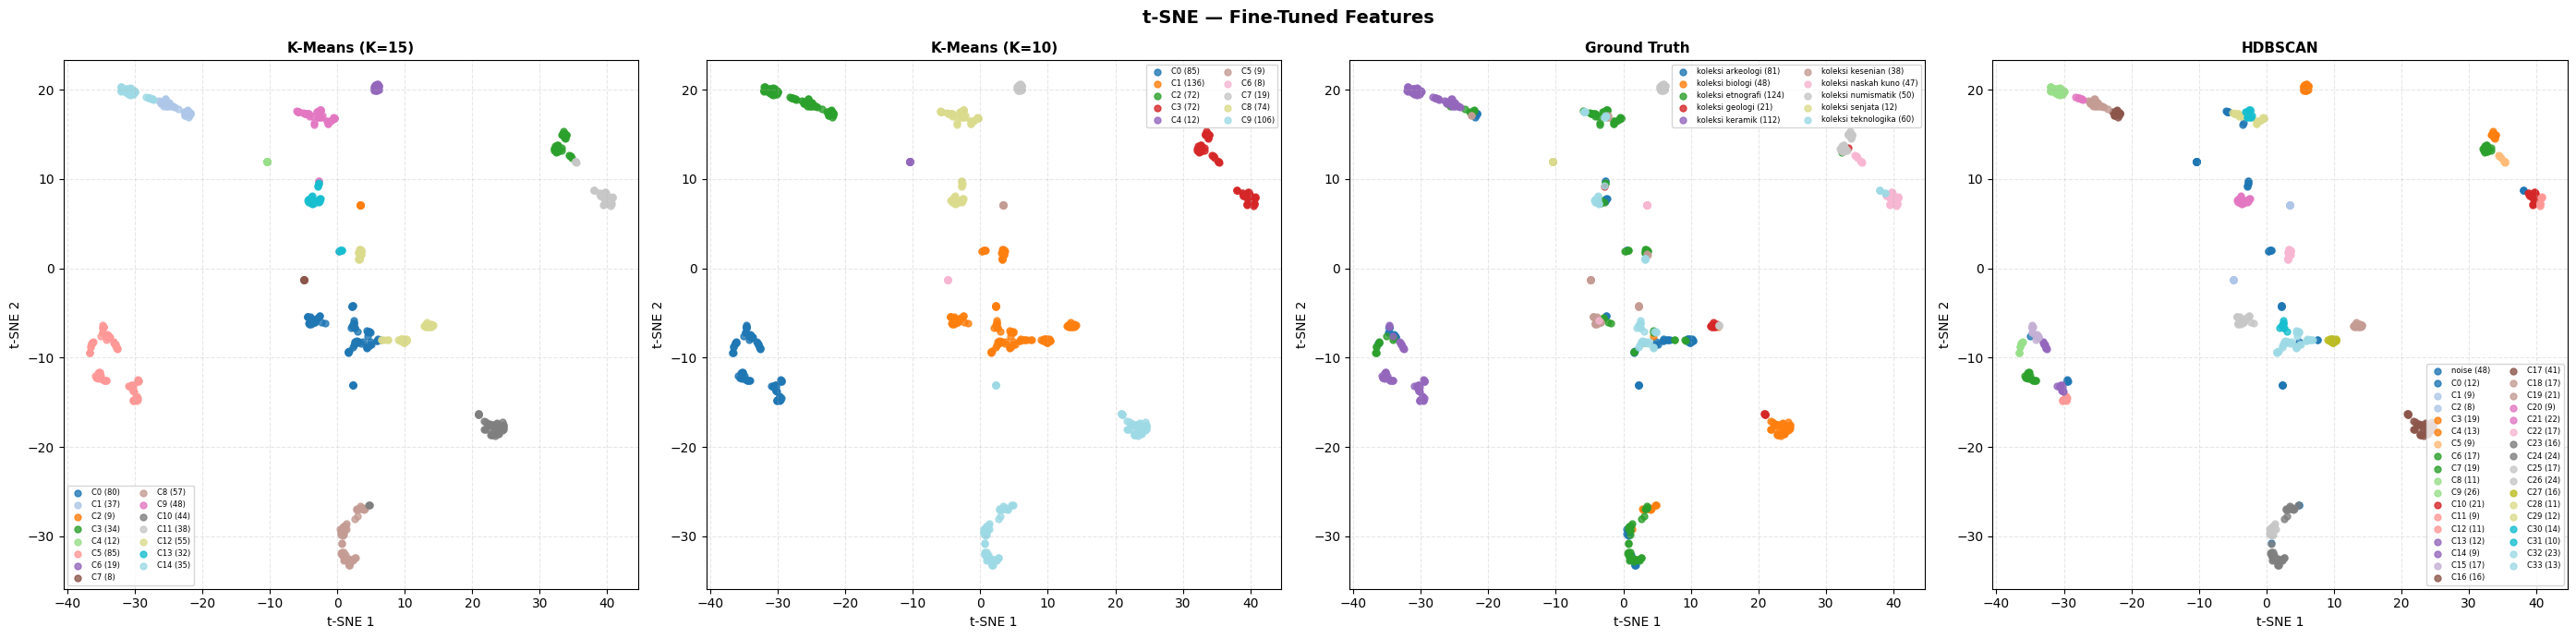

In [50]:
print('t-SNE...')
pca_50 = PCA(n_components=min(50,features_final.shape[1]), random_state=SEED)
tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED, verbose=1)
feat_tsne = tsne.fit_transform(pca_50.fit_transform(features_final))

configs_t = [
    (km_labels_opt, f'K-Means (K={K_OPTIMAL})'),
    (km_labels,     'K-Means (K=10)'),
    (gt_labels,     'Ground Truth'),
]
if HDBSCAN_OK and hdb_labels is not None:
    configs_t.append((hdb_labels, 'HDBSCAN'))
n_p = len(configs_t)
fig, axes = plt.subplots(1,n_p,figsize=(7*n_p,7))
if n_p==1: axes=[axes]
for ax,(lbl_t,ttl_t) in zip(axes,configs_t):
    unique_lbl = sorted(set(lbl_t))
    cmap_fn = plt.cm.get_cmap('tab20', len(unique_lbl))
    for i,cl in enumerate(unique_lbl):
        mask = lbl_t==cl
        lbl_s = class_names[cl] if ttl_t=='Ground Truth' else ('noise' if cl==-1 else f'C{cl}')
        ax.scatter(feat_tsne[mask,0],feat_tsne[mask,1],s=25,alpha=0.8,
                   color=cmap_fn(i),label=f'{lbl_s} ({mask.sum()})')
    ax.set_title(ttl_t,fontsize=11,fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=6,ncol=2); ax.grid(True,ls='--',alpha=0.3)
plt.suptitle('t-SNE — Fine-Tuned Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','04_tsne.png'), dpi=200, bbox_inches='tight'); plt.show()


## Cell 17 — Contoh Gambar per Cluster

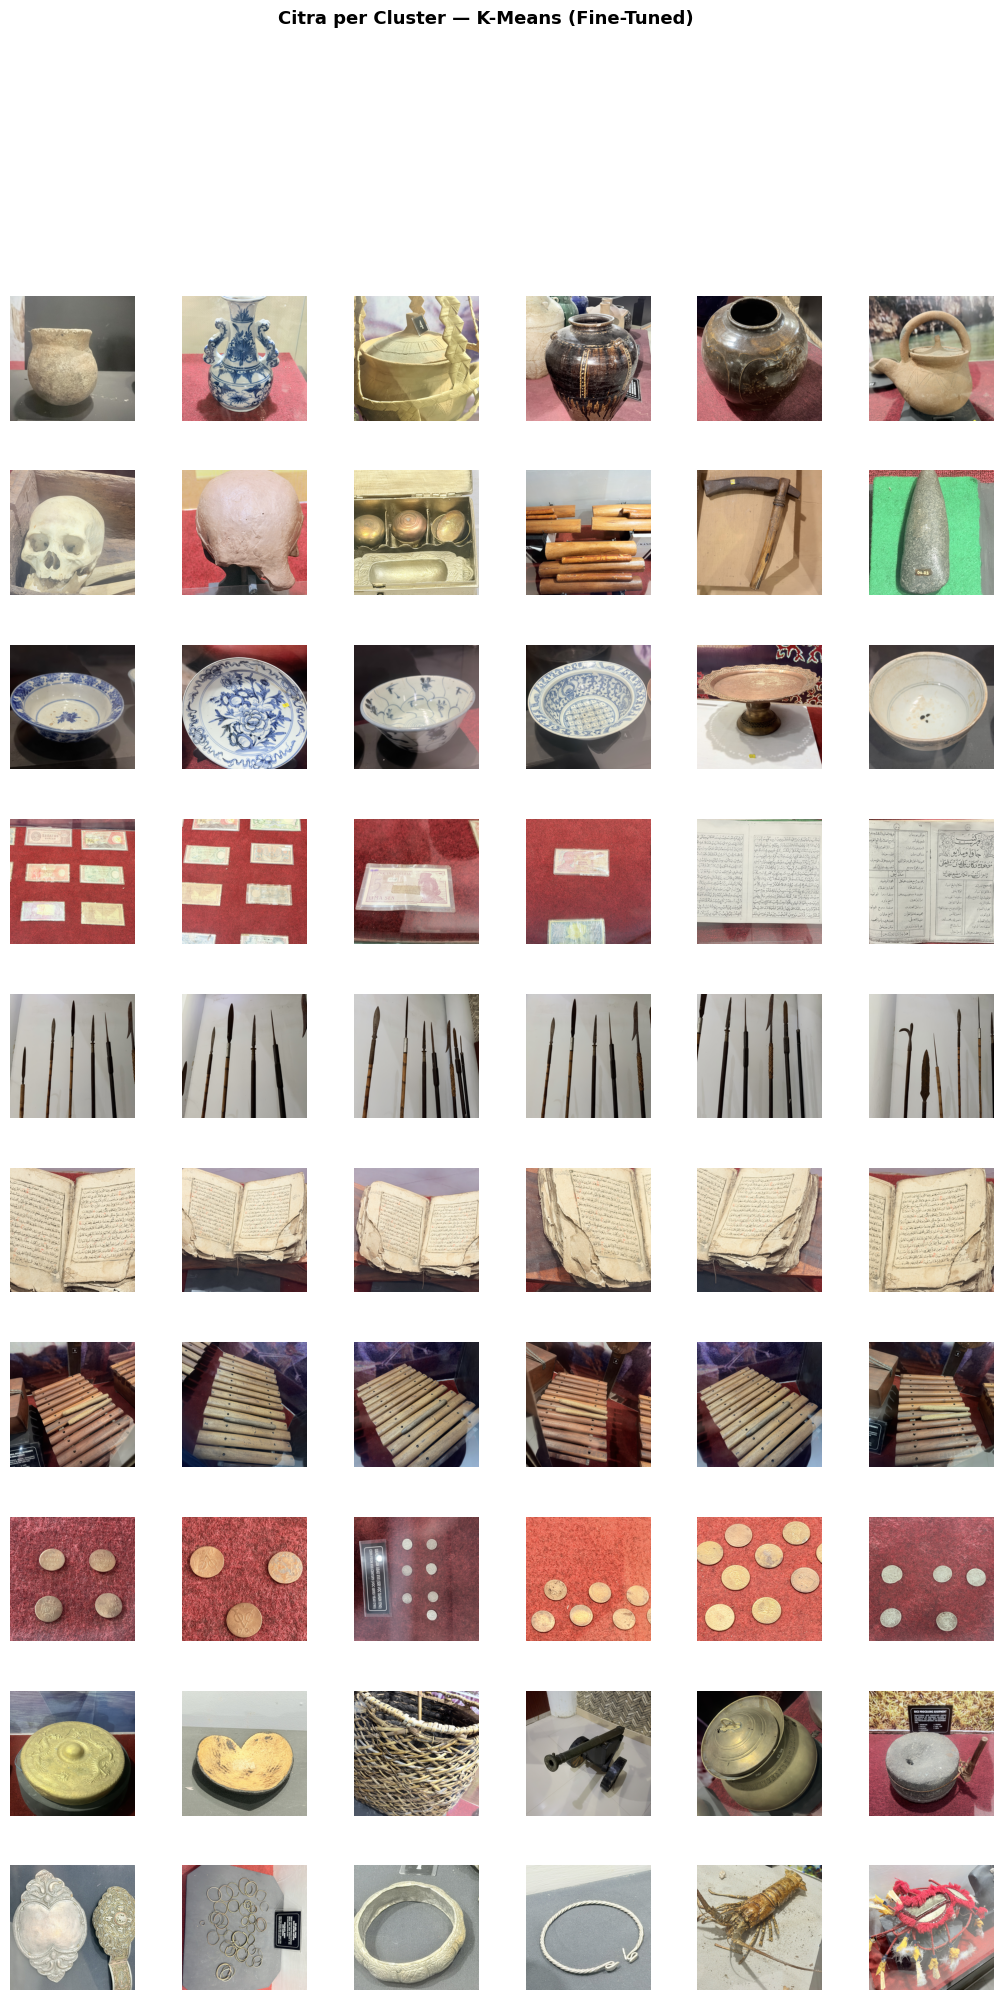

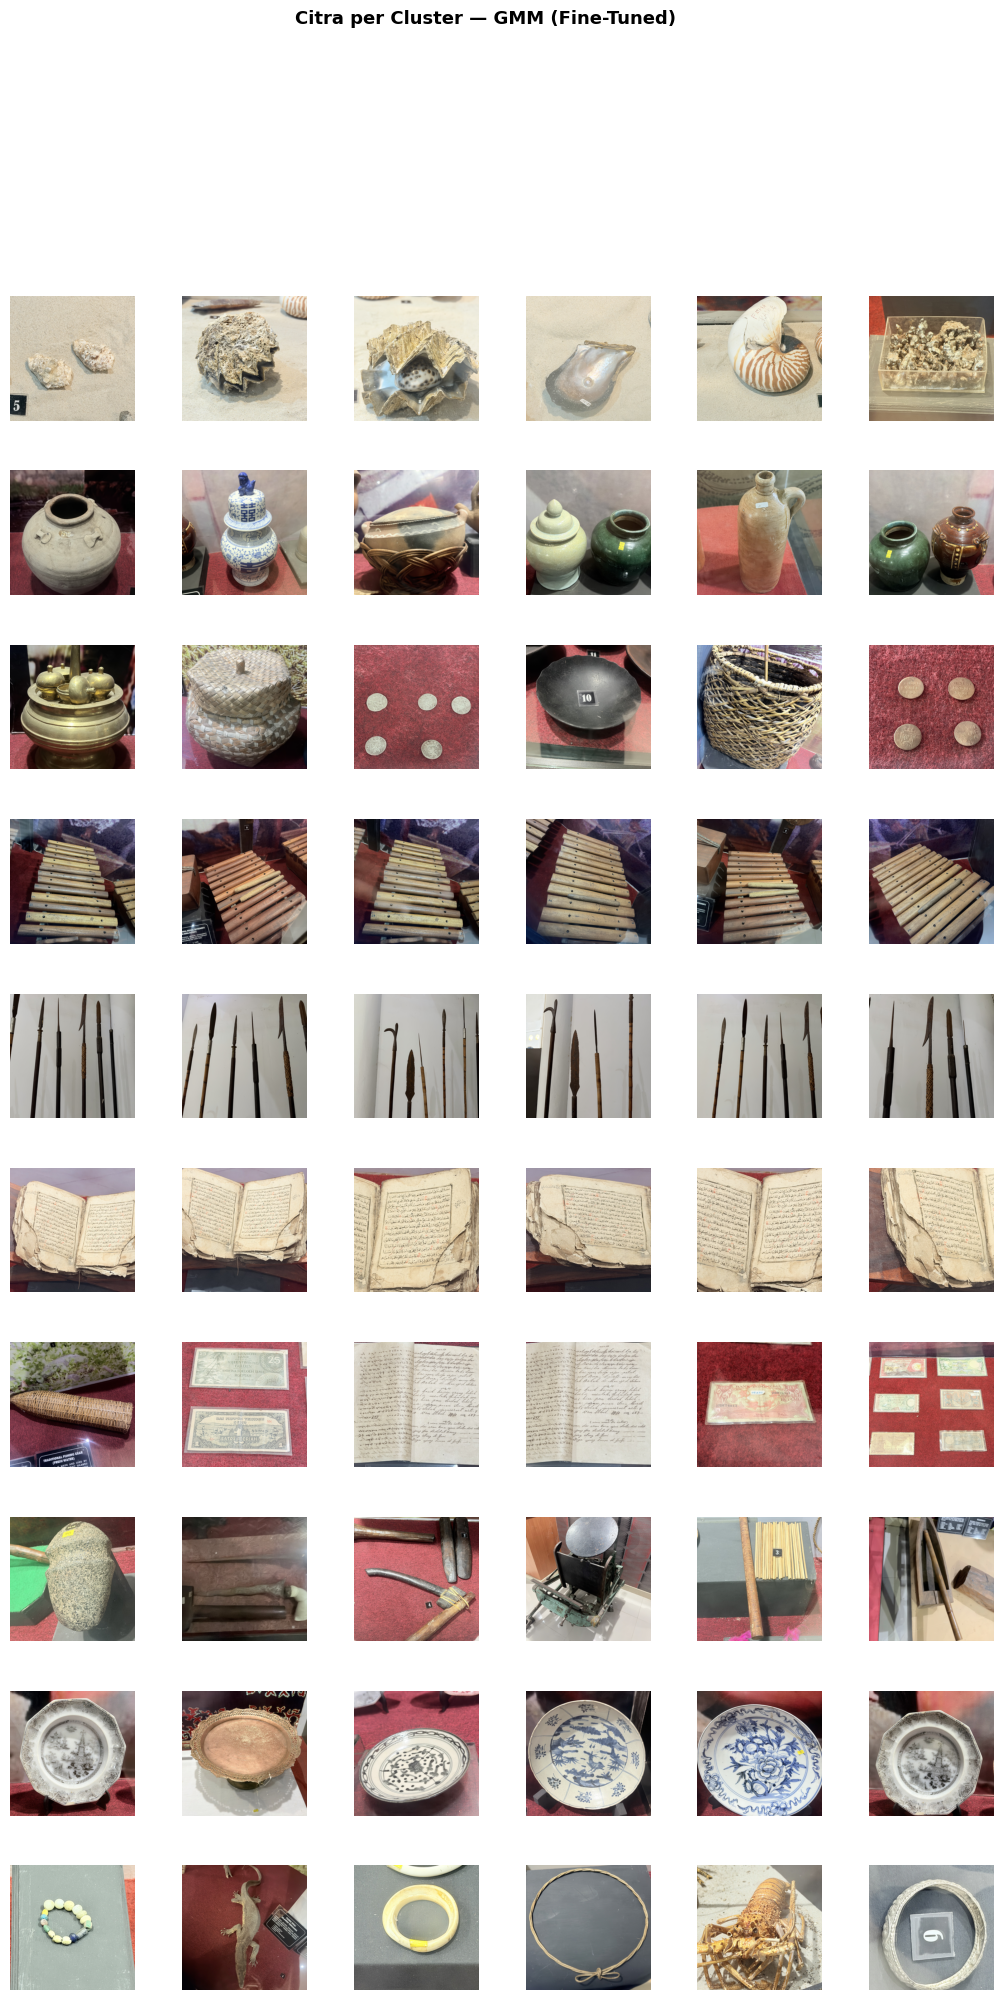

In [51]:
def plot_samples(images, labels, name_map, n_clusters, n_sample=6, title='', save_path=None):
    valid_cls = [cl for cl in range(n_clusters) if np.any(labels==cl)]
    fig = plt.figure(figsize=(n_sample*2.2, len(valid_cls)*2.2))
    gs  = gridspec.GridSpec(len(valid_cls), n_sample, figure=fig, hspace=0.4, wspace=0.05)
    cmap_fn = plt.cm.get_cmap('tab20', len(valid_cls))
    for ri,cl in enumerate(valid_cls):
        idx_cl = np.where(labels==cl)[0]
        chosen = np.random.choice(idx_cl, min(n_sample,len(idx_cl)), replace=False)
        cat = name_map.get(cl, f'C{cl}')
        for j,img_idx in enumerate(chosen):
            ax = fig.add_subplot(gs[ri,j])
            img_show = images[img_idx]
            ax.imshow(np.clip(img_show/255.0 if img_show.max()>1 else img_show,0,1))
            ax.axis('off')
            if j==0:
                ax.set_ylabel(f'C{cl}\n({len(idx_cl)})\n{cat}',
                              fontsize=7,rotation=0,labelpad=60,va='center',color=cmap_fn(ri))
    fig.suptitle(f'Citra per Cluster — {title}', fontsize=13, fontweight='bold', y=1.01)
    if save_path: plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

plot_samples(images, km_labels,  km_cluster_names,  N_CLUSTERS, CONFIG['n_sample_vis'],
    'K-Means (Fine-Tuned)', os.path.join(CONFIG['output_root'],'grafik','05_cluster_km.png'))
plot_samples(images, gmm_labels, gmm_cluster_names, N_CLUSTERS, CONFIG['n_sample_vis'],
    'GMM (Fine-Tuned)',     os.path.join(CONFIG['output_root'],'grafik','06_cluster_gmm.png'))


## Cell 18 — Simpan Hasil

In [52]:
def save_clusters(image_paths, labels, n_clusters, output_dir, method='kmeans', cluster_names=None):
    base_dir = os.path.join(output_dir, f'cluster_{method}')
    for cl in sorted(set(labels)):
        folder = 'noise' if cl==-1 else f'cluster_{cl:02d}__{(cluster_names or {}).get(cl,"?").replace(" ","_")}'
        os.makedirs(os.path.join(base_dir,folder), exist_ok=True)
    manifest = []
    for path,lbl in tqdm(zip(image_paths,labels),total=len(image_paths),desc=f'Save {method}'):
        fname  = os.path.basename(path)
        folder = 'noise' if lbl==-1 else f'cluster_{lbl:02d}__{(cluster_names or {}).get(int(lbl),"?").replace(" ","_")}'
        dest   = os.path.join(base_dir, folder, fname)
        if os.path.exists(dest):
            b,e = os.path.splitext(fname); dest = os.path.join(base_dir,folder,f'{b}_{np.random.randint(9999)}{e}')
        shutil.copy2(path, dest)
        manifest.append({'path':path,'cluster':int(lbl),'category':(cluster_names or {}).get(int(lbl),'?') if lbl!=-1 else 'noise',
                          'gt_folder':os.path.basename(os.path.dirname(path)),'dest':dest})
    mpath = os.path.join(output_dir, f'manifest_{method}.csv')
    with open(mpath,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=list(manifest[0].keys())); w.writeheader(); w.writerows(manifest)
    print(f'[{method}] → {base_dir}')

save_clusters(paths_ok, km_labels,  N_CLUSTERS, CONFIG['output_root'], 'kmeans',  km_cluster_names)
save_clusters(paths_ok, gmm_labels, N_CLUSTERS, CONFIG['output_root'], 'gmm',     gmm_cluster_names)
if HDBSCAN_OK and hdb_labels is not None:
    n_h = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    save_clusters(paths_ok, hdb_labels, n_h, CONFIG['output_root'], 'hdbscan', {})


Save kmeans: 100%|██████████| 593/593 [00:01<00:00, 310.47it/s]


[kmeans] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned/cluster_kmeans


Save gmm: 100%|██████████| 593/593 [00:01<00:00, 425.90it/s]


[gmm] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned/cluster_gmm


Save hdbscan: 100%|██████████| 593/593 [00:01<00:00, 336.76it/s]

[hdbscan] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned/cluster_hdbscan


## Cell 19 — Ringkasan Akhir

In [53]:
print('\n'+'='*75)
print(' RINGKASAN AKHIR — FINE-TUNED CLUSTERING')
print('='*75)
print(f'Dataset          : {len(images)} gambar | {len(class_names)} kategori')
print(f'Backbone         : EfficientNetV2B2 (fine-tuned {CONFIG["ft_phase2_epochs"]} epoch Fase2)')
print(f'Val Accuracy     : {best_val_acc*100:.1f}% (setelah fine-tuning)')
print(f'Reduksi          : {REDUCTION}')
print(f'K Optimal        : {K_OPTIMAL}')
print()

all_results = [
    (f'K-Means (K={K_OPTIMAL})', km_scores_opt['sil'], km_scores_opt['dbi'],
     sil_2d_results.get(f'K-Means (K={K_OPTIMAL})',{}).get('2d','N/A'), 'N/A'),
    ('K-Means (K=10)',  km_scores['sil'],  km_scores['dbi'],
     sil_2d_results.get('K-Means (K=10)',{}).get('2d','N/A'), f'{acc_km*100:.1f}%'),
    ('GMM (K=10)',      gmm_scores['sil'], gmm_scores['dbi'],
     sil_2d_results.get('GMM (K=10)',{}).get('2d','N/A'), f'{acc_gmm*100:.1f}%'),
]
if HDBSCAN_OK and hdb_scores['sil']:
    all_results.append(('HDBSCAN (auto)', hdb_scores['sil'], hdb_scores['dbi'], 'N/A', 'N/A'))

print(f'{"Metode":<22} {"Sil(ND)":>10} {"Sil(2D)":>10} {"DBI":>8} {"Acc":>8}')
print('-'*63)
best_sil = -1; best_method = ''
for name,sil_nd,dbi,sil_2d,acc in all_results:
    s2d_s = f'{sil_2d:.4f}' if isinstance(sil_2d,float) else str(sil_2d)
    print(f'{name:<22} {sil_nd:>10.4f} {s2d_s:>10} {dbi:>8.4f} {acc:>8}')
    if sil_nd > best_sil: best_sil=sil_nd; best_method=name
print('='*63)
print(f'Metode terbaik (ND): {best_method} = {best_sil:.4f}')

# Cek target
target = 0.85
if best_sil >= target:
    print(f'\n✅ TARGET {target} TERCAPAI! ({best_sil:.4f} ≥ {target})')
else:
    print(f'\n⚠ Target {target} belum tercapai. Best: {best_sil:.4f}')
    print(f'   Gap: {target - best_sil:.4f} — pertimbangkan Sil(2D) sebagai metrik pelaporan.')
print()
print(f'Output dir: {CONFIG["output_root"]}')
print('='*75)

summary = {
    'backbone': 'EfficientNetV2B2 (fine-tuned)',
    'val_accuracy': float(best_val_acc),
    'reduction': REDUCTION, 'k_optimal': int(K_OPTIMAL),
    'results': {name:{'sil_nd':round(s,4),'dbi':round(d,4)}
                for name,s,d,*_ in all_results},
    'sil_2d': sil_2d_results,
    'hungarian_accuracy': {'kmeans': float(round(acc_km,4)), 'gmm': float(round(acc_gmm,4))}
}
with open(os.path.join(CONFIG['output_root'],'ringkasan_final.json'),'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('Ringkasan tersimpan!')



 RINGKASAN AKHIR — FINE-TUNED CLUSTERING
Dataset          : 593 gambar | 10 kategori
Backbone         : EfficientNetV2B2 (fine-tuned 50 epoch Fase2)
Val Accuracy     : 87.6% (setelah fine-tuning)
Reduksi          : PCA128D + UMAP50D
K Optimal        : 15

Metode                    Sil(ND)    Sil(2D)      DBI      Acc
---------------------------------------------------------------
K-Means (K=15)             0.5963     0.2082   0.5223      N/A
K-Means (K=10)             0.5409     0.1560   0.5616    44.0%
GMM (K=10)                 0.5372     0.2611   0.5881    42.3%
HDBSCAN (auto)             0.6576        N/A   0.4744      N/A
Metode terbaik (ND): HDBSCAN (auto) = 0.6576

⚠ Target 0.85 belum tercapai. Best: 0.6576
   Gap: 0.1924 — pertimbangkan Sil(2D) sebagai metrik pelaporan.

Output dir: /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_finetuned
Ringkasan tersimpan!
